# LME: intensidad subjetiva de DMT e hipnodensidades EEG

Análisis exclusivo de la sesión DMT. Usa los ratings de `Intensity` con el encoding Excel B=−8, C=−4, D=0 y E:O=1, 2, 3, 4, 6, 10, 14, 18, 22, 26, 30 min; los alinea con EEG añadiendo 14 minutos. Para cada rating se promedian, ponderadas por solapamiento, las épocas que intersectan los 60 segundos anteriores al instante EEG alineado. El baseline es la media de **todas** las épocas preinfusión por sujeto y electrodo.

No se hace pairing ni contraste con placebo, y el modelo principal usa `intensity` (no `intensity_within`).

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from IPython.display import display

RATINGS_PATH = Path('/home/rherzoga/Documentos/Projects/Timmerman/data/ES_ratings.xlsx')
RUN_NAME = 'gap_sensitivity_000s_gssc_yasa_sleepfm_cpu_v1'
RUN_ROOT = next(path.resolve() for path in (Path('outputs') / RUN_NAME, Path('../outputs') / RUN_NAME) if path.is_dir())
RECORDINGS_DIR = RUN_ROOT / 'recordings'
OUTPUT_DIR = RUN_ROOT.parent / 'intensity_lme_analysis_gssc_v1'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Main LME encoding: Excel D=0, then E:O=[1, 2, 3, 4, 6, 10, 14, 18, 22, 26, 30].
TIMEPOINTS_MIN = (0, 1, 2, 3, 4, 6, 10, 14, 18, 22, 26, 30)
EEG_OFFSET_SECONDS = 14 * 60
WINDOW_SECONDS = 60
INFUSION_START_SECONDS = 14 * 60
STAGER = 'gssc'
RESPONSES = ('prob_W', 'prob_N1', 'prob_R', 'entropy')
RESPONSE_LABELS = {'prob_W': 'Wake', 'prob_N1': 'N1', 'prob_R': 'REM', 'entropy': 'Entropy'}
MODEL_FORMULA = 'response ~ intensity + C(timepoint)'

assert len(TIMEPOINTS_MIN) == 12
display({'ratings': str(RATINGS_PATH), 'recordings': str(RECORDINGS_DIR), 'formula': MODEL_FORMULA})

{'ratings': '/home/rherzoga/Documentos/Projects/Timmerman/data/ES_ratings.xlsx',
 'recordings': '/home/rherzoga/Documentos/Projects/Timmerman/dmt_hypnodensities/outputs/gap_sensitivity_000s_gssc_yasa_sleepfm_cpu_v1/recordings',
 'formula': 'response ~ intensity + C(timepoint)'}

## Ratings y épocas EEG

La lectura con `usecols='D:O'` implementa literalmente el encoding corregido: D=0 y E:O son los once puntos postinfusión. B y C (−8 y −4 min) se reservan para la figura descriptiva.

In [2]:
subject_column = pd.read_excel(RATINGS_PATH, sheet_name='Intensity', header=None, usecols='A').iloc[:, 0]
ratings_wide = pd.read_excel(RATINGS_PATH, sheet_name='Intensity', header=None, usecols='D:O')
ratings_wide.columns = TIMEPOINTS_MIN
ratings_wide.insert(0, 'subject', subject_column.astype(str))
ratings = ratings_wide.melt('subject', var_name='timepoint', value_name='intensity')
ratings['timepoint'] = ratings['timepoint'].astype(int)
ratings['intensity'] = pd.to_numeric(ratings['intensity'], errors='coerce')
ratings = ratings.dropna(subset=['intensity']).reset_index(drop=True)
ratings['eeg_window_end'] = EEG_OFFSET_SECONDS + ratings['timepoint'] * 60
ratings['eeg_window_start'] = ratings['eeg_window_end'] - WINDOW_SECONDS

files = sorted(RECORDINGS_DIR.glob('*_hypnodensities.parquet'))
if not files:
    raise FileNotFoundError(f'No hypnodensity files found in {RECORDINGS_DIR}')
eeg = pd.concat([pd.read_parquet(file) for file in files], ignore_index=True)
eeg = eeg.loc[eeg['condition'].astype(str).eq('DMT') & eeg['stager'].astype(str).eq(STAGER)].copy()
probabilities = ['prob_W', 'prob_N1', 'prob_N2', 'prob_N3', 'prob_R']

def normalized_entropy(probability_values):
    """Shannon entropy of the five-state mean hypnodensity, normalized to [0, 1]."""
    probability_values = np.asarray(probability_values, dtype=float)
    return -np.where(probability_values > 0, probability_values * np.log(probability_values), 0.0).sum() / np.log(5)

ratings = ratings.loc[ratings['subject'].isin(eeg['subject'].astype(str).unique())].copy()
display({'DMT EEG rows': len(eeg), 'ratings after DMT-subject restriction': len(ratings), 'DMT subjects': eeg['subject'].nunique()})

{'DMT EEG rows': 20864,
 'ratings after DMT-subject restriction': 189,
 'DMT subjects': 18}

In [3]:
# All epochs strictly preinfusion, averaged separately for every subject and electrode.
baseline = (
    eeg.loc[eeg['absolute_end'].le(INFUSION_START_SECONDS)]
    .groupby(['subject', 'electrode'], observed=True)[probabilities]
    .mean()
)

window_rows, coverage_rows = [], []
for rating in ratings.itertuples(index=False):
    candidates = eeg.loc[
        eeg['subject'].astype(str).eq(rating.subject)
        & eeg['absolute_start'].lt(rating.eeg_window_end)
        & eeg['absolute_end'].gt(rating.eeg_window_start)
    ].copy()
    candidates['overlap_seconds'] = (
        np.minimum(candidates['absolute_end'], rating.eeg_window_end)
        - np.maximum(candidates['absolute_start'], rating.eeg_window_start)
    )
    candidates = candidates.loc[candidates['overlap_seconds'].gt(0)]
    coverage_rows.append({
        'subject': rating.subject, 'timepoint': rating.timepoint, 'intensity': rating.intensity,
        'n_overlapping_epochs': len(candidates),
        'overlap_seconds_all_electrodes': candidates['overlap_seconds'].sum(),
        'n_electrodes_with_overlap': candidates['electrode'].nunique(),
    })
    for electrode, epochs in candidates.groupby('electrode', observed=True):
        baseline_key = (rating.subject, electrode)
        if baseline_key not in baseline.index:
            continue
        weighted = np.average(epochs[probabilities], axis=0, weights=epochs['overlap_seconds'])
        baseline_values = baseline.loc[baseline_key, probabilities].to_numpy(dtype=float)
        window_rows.append({
            'subject': rating.subject, 'timepoint': rating.timepoint, 'intensity': rating.intensity,
            'electrode': electrode,
            # Raw paired probabilities are retained for the rating-level analysis below.
            'paired_prob_W': weighted[0],
            'paired_prob_N1': weighted[1],
            'paired_prob_N2': weighted[2],
            'paired_prob_N3': weighted[3],
            'paired_prob_R': weighted[4],
            'prob_W': weighted[0] - baseline_values[0],
            'prob_N1': weighted[1] - baseline_values[1],
            'prob_R': weighted[4] - baseline_values[4],
            'entropy': normalized_entropy(weighted) - normalized_entropy(baseline_values),
        })

coverage = pd.DataFrame(coverage_rows)
analysis = pd.DataFrame(window_rows)
coverage['has_valid_eeg_rating'] = coverage.set_index(['subject', 'timepoint']).index.isin(
    analysis[['subject', 'timepoint']].drop_duplicates().set_index(['subject', 'timepoint']).index
)
coverage_table = coverage.sort_values(['timepoint', 'subject']).reset_index(drop=True)
validity_table = (coverage.groupby('timepoint', observed=True)
    .agg(ratings_in_excel=('subject', 'size'), valid_ratings=('has_valid_eeg_rating', 'sum'),
         valid_subjects=('subject', lambda x: x[coverage.loc[x.index, 'has_valid_eeg_rating']].nunique()),
         median_overlap_seconds_all_electrodes=('overlap_seconds_all_electrodes', 'median'))
    .reset_index())
subject_validity_table = (coverage.loc[coverage['has_valid_eeg_rating']].groupby('subject', observed=True)
    .size().rename('valid_ratings').reset_index().sort_values('subject'))

coverage_table.to_csv(OUTPUT_DIR / 'rating_eeg_coverage.csv', index=False)
validity_table.to_csv(OUTPUT_DIR / 'rating_validity_by_timepoint.csv', index=False)
subject_validity_table.to_csv(OUTPUT_DIR / 'valid_ratings_by_subject.csv', index=False)
display(validity_table)
display({'valid ratings': int(coverage['has_valid_eeg_rating'].sum()), 'valid subjects': analysis['subject'].nunique(), 'electrode-level rows': len(analysis)})

,timepoint,ratings_in_excel,valid_ratings,valid_subjects,median_overlap_seconds_all_electrodes
0,0,16,12,12,959.936
1,1,16,1,1,0.000
2,2,16,1,1,0.000
3,3,16,2,2,0.000
4,4,16,3,3,0.000
5,6,16,2,2,0.000
6,10,16,4,4,0.000
7,14,16,6,6,0.000
8,18,16,4,4,0.000
9,22,16,3,3,0.000


{'valid ratings': 46, 'valid subjects': 14, 'electrode-level rows': 1472}

## Modelos LME

Cada respuesta es el cambio respecto a baseline. Se ajusta un intercepto aleatorio por sujeto y un componente de varianza para electrodo: `vc_formula = {'electrode': '0 + C(electrode)'}`. La corrección FDR Benjamini–Hochberg se aplica a las cuatro pruebas de intensidad.

In [4]:
def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    adjusted = np.full(p_values.shape, np.nan)
    finite = np.flatnonzero(np.isfinite(p_values))
    if finite.size:
        ordered = finite[np.argsort(p_values[finite])]
        ranked = p_values[ordered] * finite.size / np.arange(1, finite.size + 1)
        adjusted[ordered] = np.minimum.accumulate(ranked[::-1])[::-1].clip(max=1)
    return adjusted

model_rows = []
for response_name in RESPONSES:
    model_data = analysis[['subject', 'electrode', 'timepoint', 'intensity', response_name]].dropna().rename(columns={response_name: 'response'})
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        fit = smf.mixedlm(
            MODEL_FORMULA, data=model_data, groups=model_data['subject'],
            vc_formula={'electrode': '0 + C(electrode)'}, re_formula='1',
        ).fit(reml=False, method='lbfgs', maxiter=1000, disp=False)
    ci = fit.conf_int().loc['intensity']
    model_rows.append({
        'variable': RESPONSE_LABELS[response_name], 'response': response_name,
        'beta': float(fit.fe_params['intensity']), 'standard_error': float(fit.bse_fe['intensity']),
        'ci95_low': float(ci.iloc[0]), 'ci95_high': float(ci.iloc[1]),
        'z_value': float(fit.tvalues['intensity']), 'p_value': float(fit.pvalues['intensity']),
        'aic': float(fit.aic), 'n_observations': len(model_data),
        'n_valid_ratings': model_data[['subject', 'timepoint']].drop_duplicates().shape[0],
        'n_subjects': model_data['subject'].nunique(), 'converged': bool(fit.converged),
    })

lme_results = pd.DataFrame(model_rows)
lme_results['p_fdr_bh'] = benjamini_hochberg(lme_results['p_value'])
lme_results.to_csv(OUTPUT_DIR / 'intensity_lme_results.csv', index=False)
display(lme_results[['variable', 'beta', 'standard_error', 'ci95_low', 'ci95_high', 'z_value', 'p_value', 'p_fdr_bh', 'aic', 'n_subjects', 'n_valid_ratings']].round(4))

,variable,beta,standard_error,ci95_low,ci95_high,z_value,p_value,p_fdr_bh,aic,n_subjects,n_valid_ratings
0,Wake,0.0607,0.0046,0.0516,0.0697,13.1204,0.0000,0.0000,-585.7360,14,46
1,N1,-0.0334,0.0042,-0.0415,-0.0252,-8.0038,0.0000,0.0000,-955.5983,14,46
2,REM,-0.0040,0.0007,-0.0054,-0.0026,-5.5445,0.0000,0.0000,-6084.2466,14,46
3,Entropy,-0.0081,0.0031,-0.0142,-0.0020,-2.6097,0.0091,0.0091,-1509.2315,14,46


,subject,timepoint,intensity,response,mean_change_from_baseline,swarm_offset,swarm_timepoint
225,P07,-8,0.0,entropy,-0.214348,-0.280000,-8.280000
228,P08,-8,0.0,entropy,0.037819,-0.236923,-8.236923
236,P09,-8,0.0,entropy,-0.013618,-0.193846,-8.193846
241,P10,-8,0.0,entropy,-0.086554,-0.150769,-8.150769
247,P11,-8,0.0,entropy,0.001994,-0.107692,-8.107692
...,...,...,...,...,...,...,...
10,P08,30,6.0,prob_W,0.033606,-0.280000,29.720000
15,P09,30,4.0,prob_W,-0.156602,-0.140000,29.860000
21,P10,30,3.0,prob_W,-0.210888,0.000000,30.000000
32,P13,30,3.0,prob_W,-0.154849,0.140000,30.140000


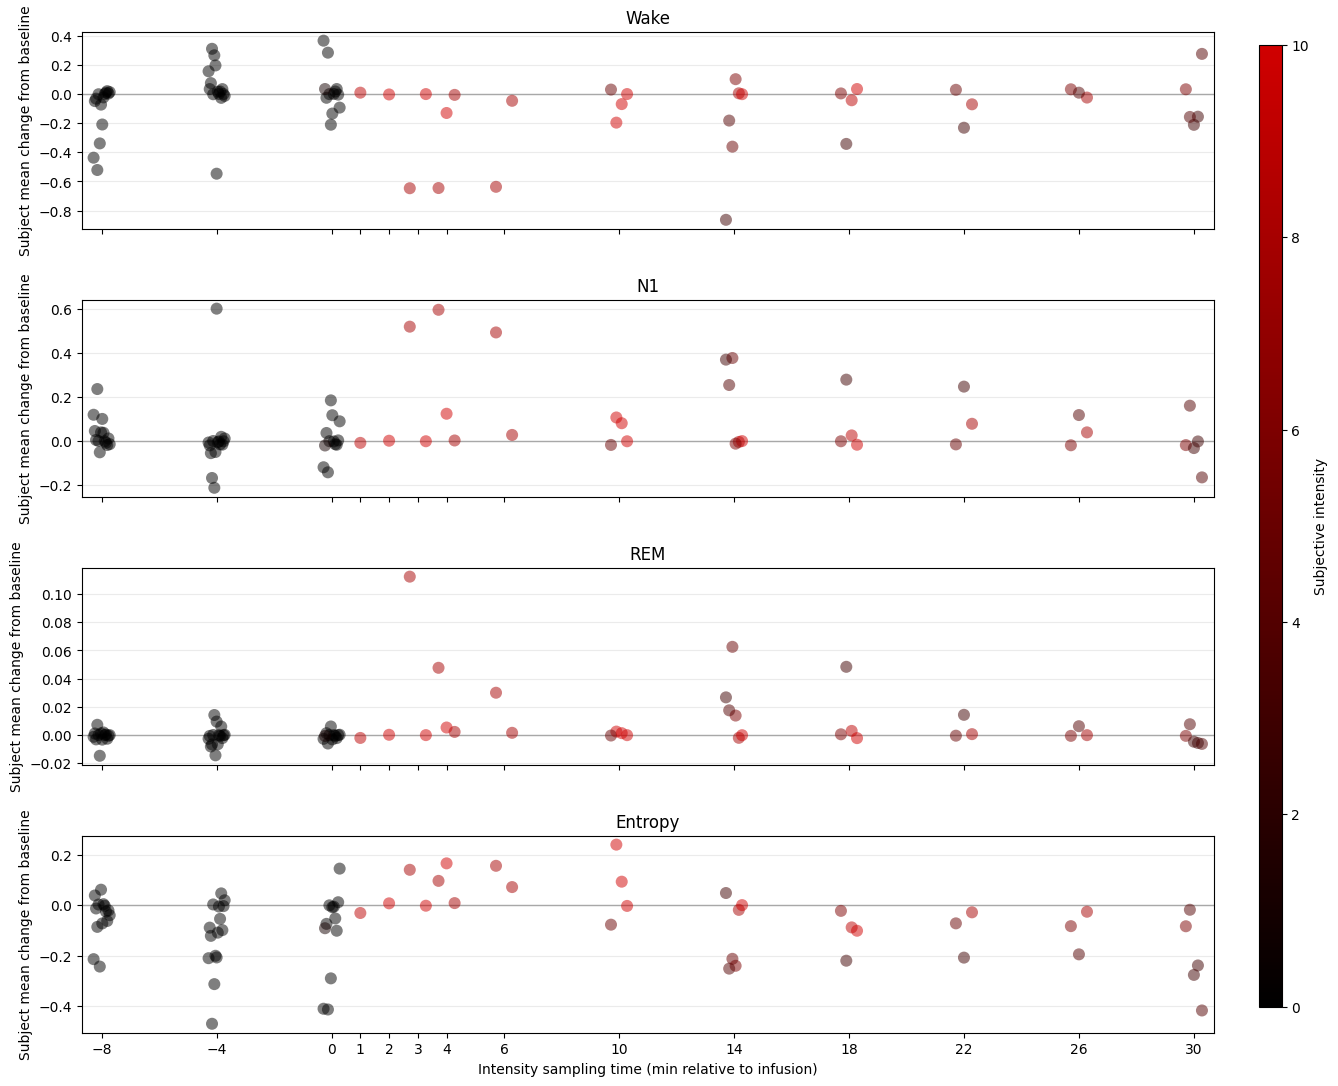

In [5]:
# Figure-only extension: Excel B and C are the ratings at −8 and −4 minutes.
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

FIGURE_TIMEPOINTS_MIN = (-8, -4, *TIMEPOINTS_MIN)
figure_ratings_wide = pd.read_excel(RATINGS_PATH, sheet_name='Intensity', header=None, usecols='B:O')
figure_ratings_wide.columns = FIGURE_TIMEPOINTS_MIN
figure_ratings_wide.insert(0, 'subject', subject_column.astype(str))
figure_ratings = figure_ratings_wide.melt('subject', var_name='timepoint', value_name='intensity')
figure_ratings['timepoint'] = figure_ratings['timepoint'].astype(int)
figure_ratings['intensity'] = pd.to_numeric(figure_ratings['intensity'], errors='coerce')
figure_ratings = figure_ratings.dropna(subset=['intensity'])
figure_ratings = figure_ratings.loc[figure_ratings['subject'].isin(eeg['subject'].astype(str).unique())].copy()
figure_ratings['eeg_window_end'] = EEG_OFFSET_SECONDS + figure_ratings['timepoint'] * 60
figure_ratings['eeg_window_start'] = figure_ratings['eeg_window_end'] - WINDOW_SECONDS

figure_rows = []
for rating in figure_ratings.itertuples(index=False):
    epochs = eeg.loc[
        eeg['subject'].astype(str).eq(rating.subject)
        & eeg['absolute_start'].lt(rating.eeg_window_end)
        & eeg['absolute_end'].gt(rating.eeg_window_start)
    ].copy()
    epochs['overlap_seconds'] = (
        np.minimum(epochs['absolute_end'], rating.eeg_window_end)
        - np.maximum(epochs['absolute_start'], rating.eeg_window_start)
    )
    for electrode, electrode_epochs in epochs.loc[epochs['overlap_seconds'].gt(0)].groupby('electrode', observed=True):
        key = (rating.subject, electrode)
        if key not in baseline.index:
            continue
        weighted = np.average(electrode_epochs[probabilities], axis=0, weights=electrode_epochs['overlap_seconds'])
        baseline_values = baseline.loc[key, probabilities].to_numpy(dtype=float)
        figure_rows.append({
            'subject': rating.subject, 'timepoint': rating.timepoint, 'intensity': rating.intensity, 'electrode': electrode,
            'prob_W': weighted[0] - baseline_values[0], 'prob_N1': weighted[1] - baseline_values[1],
            'prob_R': weighted[4] - baseline_values[4],
            'entropy': normalized_entropy(weighted) - normalized_entropy(baseline_values),
        })

# Each plotted observation is one subject × timepoint: all available electrodes are averaged first.
figure_analysis = pd.DataFrame(figure_rows)
plot_data = (
    figure_analysis.groupby(['subject', 'timepoint', 'intensity'], observed=True)[list(RESPONSES)]
    .mean().reset_index()
    .melt(id_vars=['subject', 'timepoint', 'intensity'], value_vars=list(RESPONSES),
          var_name='response', value_name='mean_change_from_baseline')
)

# Swarm-like horizontal offsets separate subjects measured at the same sampling time.
subject_positions = plot_data[['subject', 'timepoint']].drop_duplicates().sort_values(['timepoint', 'subject']).copy()
subject_positions['swarm_offset'] = subject_positions.groupby('timepoint', observed=True)['subject'].transform(
    lambda values: np.linspace(-0.28, 0.28, len(values)) if len(values) > 1 else np.array([0.0])
)
plot_data = plot_data.merge(subject_positions, on=['subject', 'timepoint'], validate='many_to_one')
plot_data['swarm_timepoint'] = plot_data['timepoint'] + plot_data['swarm_offset']

colour_map = LinearSegmentedColormap.from_list('black_to_red', ['#000000', '#d00000'])
colour_norm = Normalize(plot_data['intensity'].min(), plot_data['intensity'].max())
fig, axes = plt.subplots(4, 1, figsize=(15, 13), sharex=True)
for axis, response in zip(axes, RESPONSES):
    panel = plot_data.loc[plot_data['response'].eq(response)].sort_values('timepoint')
    axis.scatter(
        panel['swarm_timepoint'], panel['mean_change_from_baseline'], c=panel['intensity'],
        cmap=colour_map, norm=colour_norm, s=75, edgecolors='none', zorder=3, alpha=0.5,
    )
    axis.axhline(0, color='0.65', linewidth=1, zorder=0)
    axis.set_title(RESPONSE_LABELS[response])
    axis.set_ylabel('Subject mean change from baseline')
    axis.grid(axis='y', alpha=0.25)

axes[-1].set_xlabel('Intensity sampling time (min relative to infusion)')
axes[-1].set_xticks(FIGURE_TIMEPOINTS_MIN)
axes[-1].set_xlim(min(FIGURE_TIMEPOINTS_MIN) - 0.7, max(FIGURE_TIMEPOINTS_MIN) + 0.7)

fig.subplots_adjust(right=0.88, hspace=0.36)
colour_axis = fig.add_axes([0.91, 0.13, 0.015, 0.74])
colour_bar = fig.colorbar(plt.cm.ScalarMappable(norm=colour_norm, cmap=colour_map), cax=colour_axis)
colour_bar.set_label('Subjective intensity')
display(plot_data.sort_values(['response', 'timepoint', 'subject']))
plt.show()

## Modelado temporal exploratorio e intensidad individual

Estos análisis no sustituyen el LME principal. Usan los ratings postinfusión obtenidos con el encoding corregido (D=0; E:O=1…30 min). El primero suaviza el tiempo con un spline cúbico; el segundo permite que la asociación intensidad–respuesta cambie a lo largo del tiempo. El AIC se usa aquí correctamente: para comparar, dentro de una misma respuesta y con los mismos datos, el modelo suave sin interacción frente al modelo con interacción.

In [6]:
from patsy import bs
from scipy.stats import chi2

SMOOTH_TIME_FORMULA = 'response ~ intensity + bs(timepoint, df=3, degree=3)'
TIME_INTERACTION_FORMULA = 'response ~ intensity * bs(timepoint, df=3, degree=3)'
temporal_rows = []
for response_name in RESPONSES:
    model_data = (analysis[['subject', 'electrode', 'timepoint', 'intensity', response_name]]
                  .dropna().rename(columns={response_name: 'response'}))
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        smooth_fit = smf.mixedlm(
            SMOOTH_TIME_FORMULA, data=model_data, groups=model_data['subject'],
            vc_formula={'electrode': '0 + C(electrode)'}, re_formula='1',
        ).fit(reml=False, method='lbfgs', maxiter=1000, disp=False)
        interaction_fit = smf.mixedlm(
            TIME_INTERACTION_FORMULA, data=model_data, groups=model_data['subject'],
            vc_formula={'electrode': '0 + C(electrode)'}, re_formula='1',
        ).fit(reml=False, method='lbfgs', maxiter=1000, disp=False)
    df_difference = int(round(interaction_fit.df_modelwc - smooth_fit.df_modelwc))
    likelihood_ratio = max(0.0, 2 * (interaction_fit.llf - smooth_fit.llf))
    temporal_rows.append({
        'variable': RESPONSE_LABELS[response_name],
        'aic_smooth_time': float(smooth_fit.aic),
        'aic_time_interaction': float(interaction_fit.aic),
        'delta_aic_interaction_minus_smooth': float(interaction_fit.aic - smooth_fit.aic),
        'lr_statistic_interaction': likelihood_ratio,
        'lr_df': df_difference,
        'lr_p_value': float(chi2.sf(likelihood_ratio, df_difference)) if df_difference > 0 else np.nan,
        'smooth_converged': bool(smooth_fit.converged),
        'interaction_converged': bool(interaction_fit.converged),
    })

temporal_model_results = pd.DataFrame(temporal_rows)
temporal_model_results.to_csv(OUTPUT_DIR / 'exploratory_temporal_lme_comparison.csv', index=False)
display(temporal_model_results.round(4))
print('Interpretación: un ΔAIC negativo favorece la interacción; el test LR evalúa si añadirla mejora el ajuste.')

,variable,aic_smooth_time,aic_time_interaction,delta_aic_interaction_minus_smooth,lr_statistic_interaction,lr_df,lr_p_value,smooth_converged,interaction_converged
0,Wake,-340.3190,-526.6507,-186.3317,192.3317,3,0.0,True,True
1,N1,-805.4804,-932.3348,-126.8544,132.8544,3,0.0,True,True
2,REM,-5922.5082,-5977.4886,-54.9804,60.9804,3,0.0,True,True
3,Entropy,-1472.3705,-1577.2554,-104.8849,110.8849,3,0.0,True,True


Interpretación: un ΔAIC negativo favorece la interacción; el test LR evalúa si añadirla mejora el ajuste.


,subject,timepoint,intensity,response,mean_change_from_baseline
138,P07,0,0.0,entropy,-0.410804
139,P08,0,1.0,entropy,-0.091875
145,P09,0,0.0,entropy,-0.074612
148,P10,0,0.0,entropy,-0.413725
152,P11,0,0.0,entropy,-0.001182
...,...,...,...,...,...
6,P08,30,6.0,prob_W,0.033606
9,P09,30,4.0,prob_W,-0.156602
13,P10,30,3.0,prob_W,-0.210888
19,P13,30,3.0,prob_W,-0.154849


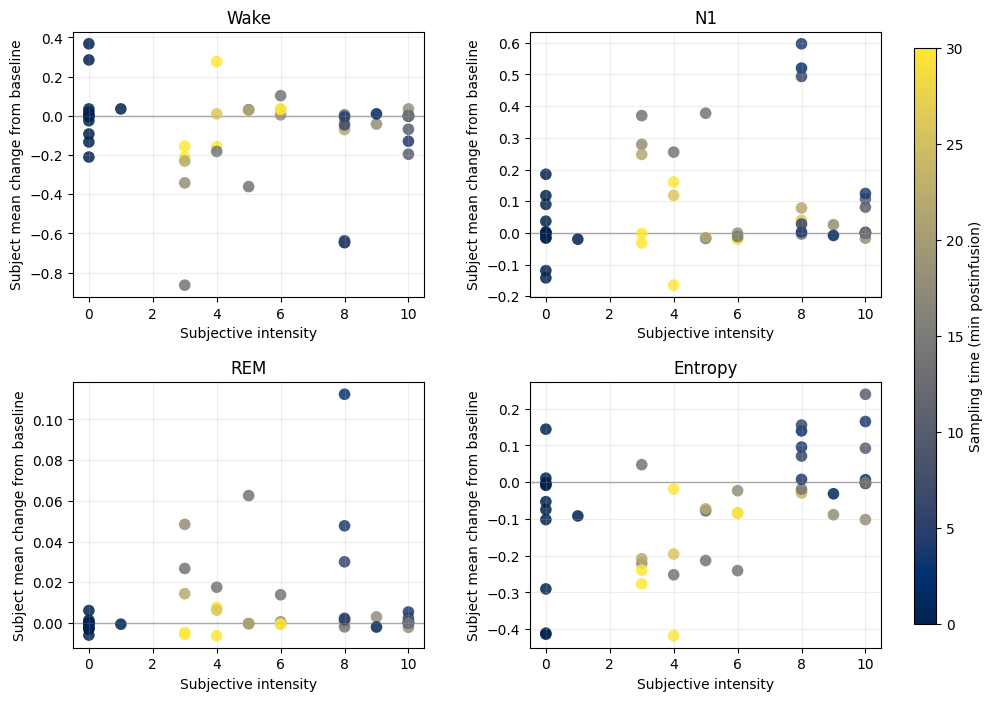

In [7]:
# One point per subject × postinfusion timepoint; electrodes are averaged before plotting.
subject_timepoint = (
    analysis.groupby(['subject', 'timepoint', 'intensity'], observed=True)[list(RESPONSES)]
    .mean().reset_index()
    .melt(id_vars=['subject', 'timepoint', 'intensity'], value_vars=list(RESPONSES),
          var_name='response', value_name='mean_change_from_baseline')
)

time_norm = Normalize(subject_timepoint['timepoint'].min(), subject_timepoint['timepoint'].max())
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for axis, response in zip(axes.flat, RESPONSES):
    panel = subject_timepoint.loc[subject_timepoint['response'].eq(response)]
    axis.scatter(
        panel['intensity'], panel['mean_change_from_baseline'], c=panel['timepoint'],
        cmap='cividis', norm=time_norm, s=70, edgecolors='none', alpha=0.85,
    )
    axis.axhline(0, color='0.65', linewidth=1, zorder=0)
    axis.set_title(RESPONSE_LABELS[response])
    axis.set_xlabel('Subjective intensity')
    axis.set_ylabel('Subject mean change from baseline')
    axis.grid(alpha=0.22)

fig.subplots_adjust(right=0.86, hspace=0.32, wspace=0.30)
colour_axis = fig.add_axes([0.89, 0.14, 0.02, 0.72])
colour_bar = fig.colorbar(plt.cm.ScalarMappable(norm=time_norm, cmap='cividis'), cax=colour_axis)
colour_bar.set_label('Sampling time (min postinfusion)')
display(subject_timepoint.sort_values(['response', 'timepoint', 'subject']))
plt.show()

## Probabilidad cruda e intensidad

Cada punto representa un `subject × intensity rating timepoint`. Las probabilidades de la ventana EEG ya emparejada se promedian entre electrodos; se muestran en escala cruda, sin normalización respecto a baseline. Entropy se calcula a partir de esas probabilidades medias crudas.


,subject,timepoint,intensity,response,mean_raw_probability
138,P07,0,0.0,entropy,0.316387
139,P08,0,1.0,entropy,0.002463
145,P09,0,0.0,entropy,0.298797
148,P10,0,0.0,entropy,0.105703
152,P11,0,0.0,entropy,0.002384
...,...,...,...,...,...
6,P08,30,6.0,prob_W,0.997684
9,P09,30,4.0,prob_W,0.712477
13,P10,30,3.0,prob_W,0.465553
19,P13,30,3.0,prob_W,0.301147


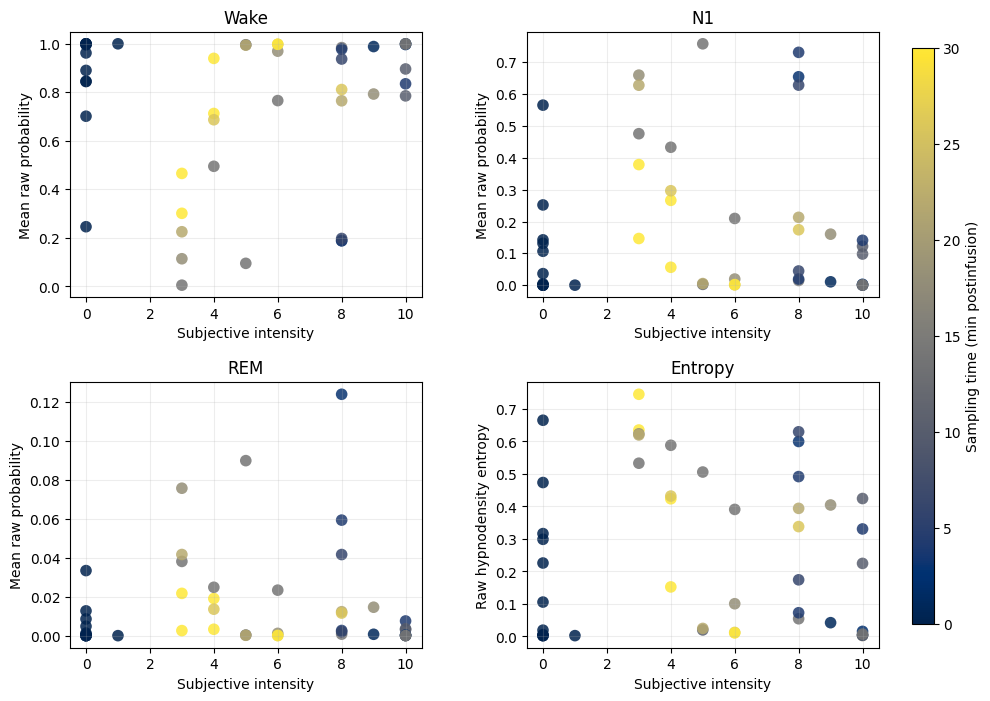

In [8]:
from matplotlib.colors import Normalize

RAW_PLOT_RESPONSES = ('prob_W', 'prob_N1', 'prob_R', 'entropy')
RAW_PROBABILITY_COLUMNS = ('paired_prob_W', 'paired_prob_N1', 'paired_prob_N2', 'paired_prob_N3', 'paired_prob_R')

# Reuse the paired 60-s observations from `analysis`. Probabilities are averaged
# over electrodes first and are deliberately kept on their raw (non-baseline) scale.
raw_subject_timepoint = (
    analysis.groupby(['subject', 'timepoint', 'intensity'], observed=True)[list(RAW_PROBABILITY_COLUMNS)]
    .mean().reset_index()
    .rename(columns={
        'paired_prob_W': 'prob_W', 'paired_prob_N1': 'prob_N1',
        'paired_prob_N2': 'prob_N2', 'paired_prob_N3': 'prob_N3', 'paired_prob_R': 'prob_R',
    })
)
raw_subject_timepoint['entropy'] = raw_subject_timepoint[
    ['prob_W', 'prob_N1', 'prob_N2', 'prob_N3', 'prob_R']
].apply(normalized_entropy, axis=1)
raw_plot_data = raw_subject_timepoint.melt(
    id_vars=['subject', 'timepoint', 'intensity'], value_vars=list(RAW_PLOT_RESPONSES),
    var_name='response', value_name='mean_raw_probability',
)

time_norm = Normalize(raw_plot_data['timepoint'].min(), raw_plot_data['timepoint'].max())
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for axis, response in zip(axes.flat, RAW_PLOT_RESPONSES):
    panel = raw_plot_data.loc[raw_plot_data['response'].eq(response)]
    axis.scatter(
        panel['intensity'], panel['mean_raw_probability'], c=panel['timepoint'],
        cmap='cividis', norm=time_norm, s=70, edgecolors='none', alpha=0.85,
    )
    axis.set_title(RESPONSE_LABELS[response])
    axis.set_xlabel('Subjective intensity')
    axis.set_ylabel('Mean raw probability' if response != 'entropy' else 'Raw hypnodensity entropy')
    axis.grid(alpha=0.22)

fig.subplots_adjust(right=0.86, hspace=0.32, wspace=0.30)
colour_axis = fig.add_axes([0.89, 0.14, 0.02, 0.72])
colour_bar = fig.colorbar(plt.cm.ScalarMappable(norm=time_norm, cmap='cividis'), cax=colour_axis)
colour_bar.set_label('Sampling time (min postinfusion)')
fig.savefig(OUTPUT_DIR / 'raw_hypnodensity_probability_vs_intensity.png', dpi=300, bbox_inches='tight')
fig.savefig(OUTPUT_DIR / 'raw_hypnodensity_probability_vs_intensity.pdf', bbox_inches='tight')
display(raw_plot_data.sort_values(['response', 'timepoint', 'subject']))
plt.show()
